In [ ]:
!unzip inventory.zip

unzip:  cannot find or open inventory.zip, inventory.zip.zip or inventory.zip.ZIP.


In [1]:
from google.colab import drive
drive.mount('/content/drive')


Mounted at /content/drive


In [ ]:
!cp inventory.zip /content/drive/MyDrive/


cp: cannot stat 'inventory.zip': No such file or directory


In [ ]:
import pandas as pd
import numpy as np
import seaborn as sns
import sqlite3

Predicting Freight Cost
Objective: Predict freight cost for a vendor invoice using quantity and dollars, to improve cost forecasting, budgeting, and vendor negotiation.

. Freight is a non-trivial component of landed cost.
. Poor freight estimates distort margin and inventory planning.
. Automating freight estimation helps procurement teams forechst true cost before invoice arrival.

In [ ]:
import os

# Create a permanent home for your project files inside Google Drive
project_path = '/content/drive/MyDrive/Freight_Cost_Project'
os.makedirs(project_path, exist_ok=True)

print("Folder created successfully at:", project_path)


Folder created successfully at: /content/drive/MyDrive/Freight_Cost_Project


In [ ]:
!mv inventory.db /content/drive/MyDrive/Freight_Cost_Project/


mv: cannot stat 'inventory.db': No such file or directory


In [ ]:
# 1. Connect to the database inside your project folder
# (If you haven't run the !mv command yet, change this path to 'inventory.db')
db_path = '/content/drive/MyDrive/Freight_Cost_Project/inventory.db'
conn = sqlite3.connect(db_path)

In [ ]:
tabled = pd.read_sql_query("select name from sqlite_master where type= 'table'", conn)

In [ ]:
print(tabled)

              name
0        purchases
1  purchase_prices
2   vendor_invoice
3  begin_inventory
4    end_inventory


In [ ]:
# Get the list of table names from the 'tabled' DataFrame
tables = tabled['name'].tolist()

for table in tables:
  print('Table name:', table)
  # Fixed syntax by removing the space after 'f'
  df = pd.read_sql_query(f"select * from {table} limit 5", conn)
  print(df)
  print('-' * 40)

Table name: purchases
           InventoryId  Store  Brand                   Description   Size  \
0    69_MOUNTMEND_8412     69   8412     Tequila Ocho Plata Fresno  750mL   
1     30_CULCHETH_5255     30   5255  TGI Fridays Ultimte Mudslide  1.75L   
2    34_PITMERDEN_5215     34   5215  TGI Fridays Long Island Iced  1.75L   
3  1_HARDERSFIELD_5255      1   5255  TGI Fridays Ultimte Mudslide  1.75L   
4    76_DONCASTER_2034     76   2034     Glendalough Double Barrel  750mL   

   VendorNumber                   VendorName  PONumber      PODate  \
0           105  ALTAMAR BRANDS LLC               8124  2023-12-21   
1          4466  AMERICAN VINTAGE BEVERAGE        8137  2023-12-22   
2          4466  AMERICAN VINTAGE BEVERAGE        8137  2023-12-22   
3          4466  AMERICAN VINTAGE BEVERAGE        8137  2023-12-22   
4           388  ATLANTIC IMPORTING COMPANY       8169  2023-12-24   

  ReceivingDate InvoiceDate     PayDate  PurchasePrice  Quantity  Dollars  \
0    2024-01-02  

In [ ]:
vendor_df = pd.read_sql_query("select * from vendor_invoice", conn)
vendor_df.head()

,VendorNumber,VendorName,InvoiceDate,PONumber,PODate,PayDate,Quantity,Dollars,Freight,Approval
0,105,ALTAMAR BRANDS LLC,2024-01-04,8124,2023-12-21,2024-02-16,6,214.26,3.47,None
1,4466,AMERICAN VINTAGE BEVERAGE,2024-01-07,8137,2023-12-22,2024-02-21,15,140.55,8.57,None
2,388,ATLANTIC IMPORTING COMPANY,2024-01-09,8169,2023-12-24,2024-02-16,5,106.60,4.61,None
3,480,BACARDI USA INC,2024-01-12,8106,2023-12-20,2024-02-05,10100,137483.78,2935.20,None
4,516,BANFI PRODUCTS CORP,2024-01-07,8170,2023-12-24,2024-02-12,1935,15527.25,429.20,None


In [ ]:
row_count = len(vendor_df)
row_count

5543

In [ ]:
vendor_df[['Quantity', 'Freight', 'Dollars']].corr()

,Quantity,Freight,Dollars
Quantity,1.000000,0.946550,0.963831
Freight,0.946550,1.000000,0.985141
Dollars,0.963831,0.985141,1.000000


<Axes: >

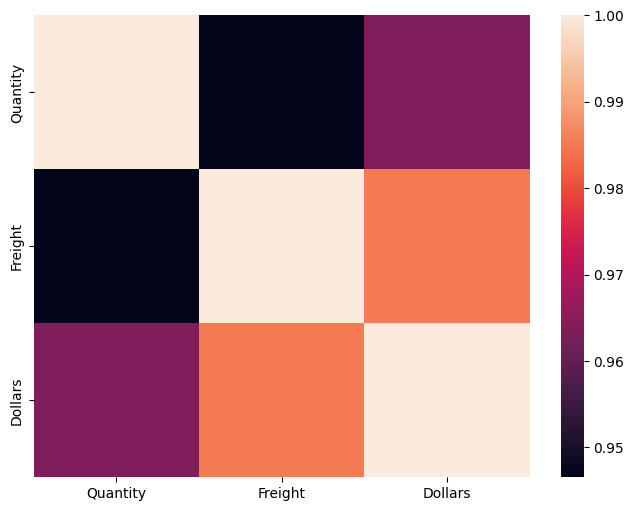

In [ ]:
import matplotlib.pyplot as plt
plt.figure(figsize= (8, 6))
sns.heatmap(vendor_df[['Quantity', 'Freight', 'Dollars']].corr())



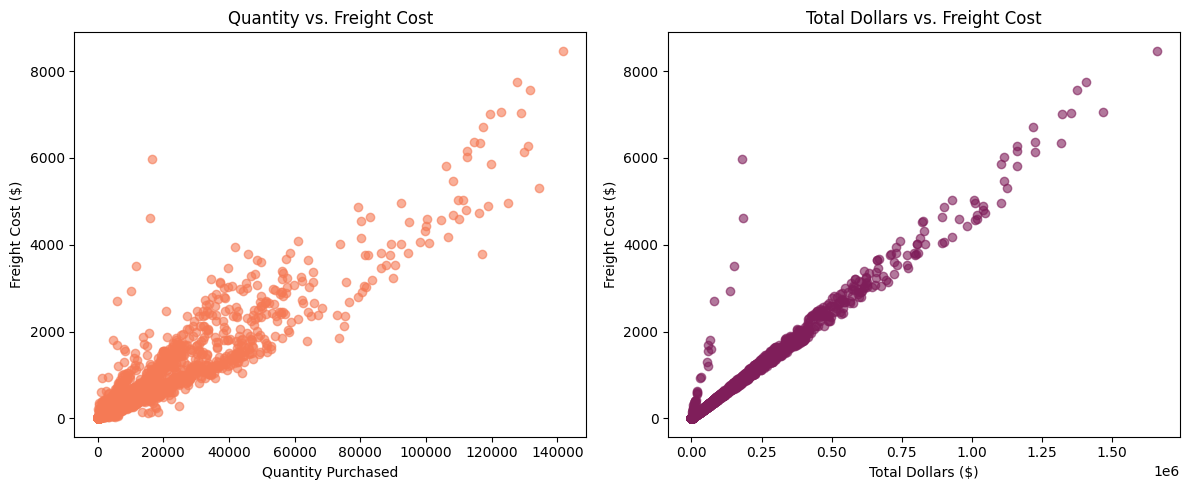

In [ ]:
import matplotlib.pyplot as plt

# Create a clean, side-by-side layout for both scatter plots
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(12, 5))

# Plot 1: Quantity vs Freight Cost
ax1.scatter(vendor_df['Quantity'], vendor_df['Freight'], color='#f57a55', alpha=0.6)
ax1.set_xlabel('Quantity Purchased')
ax1.set_ylabel('Freight Cost ($)')
ax1.set_title('Quantity vs. Freight Cost')

# Plot 2: Dollars vs Freight Cost
ax2.scatter(vendor_df['Dollars'], vendor_df['Freight'], color='#7f1e5a', alpha=0.6)
ax2.set_xlabel('Total Dollars ($)')
ax2.set_ylabel('Freight Cost ($)')
ax2.set_title('Total Dollars vs. Freight Cost')

plt.tight_layout()
plt.show()


In [ ]:
vendor_df['freight_per_unit'] = vendor_df['Freight']/vendor_df['Quantity']

vendor_df

,VendorNumber,VendorName,InvoiceDate,PONumber,PODate,PayDate,Quantity,Dollars,Freight,Approval,freight_per_unit
0,105,ALTAMAR BRANDS LLC,2024-01-04,8124,2023-12-21,2024-02-16,6,214.26,3.47,None,0.578333
1,4466,AMERICAN VINTAGE BEVERAGE,2024-01-07,8137,2023-12-22,2024-02-21,15,140.55,8.57,None,0.571333
2,388,ATLANTIC IMPORTING COMPANY,2024-01-09,8169,2023-12-24,2024-02-16,5,106.60,4.61,None,0.922000
3,480,BACARDI USA INC,2024-01-12,8106,2023-12-20,2024-02-05,10100,137483.78,2935.20,None,0.290614
4,516,BANFI PRODUCTS CORP,2024-01-07,8170,2023-12-24,2024-02-12,1935,15527.25,429.20,None,0.221809
...,...,...,...,...,...,...,...,...,...,...,...
5538,9622,WEIN BAUER INC,2025-01-06,13626,2024-12-21,2025-02-10,90,1563.00,8.60,None,0.095556
5539,9625,WESTERN SPIRITS BEVERAGE CO,2025-01-10,13661,2024-12-23,2025-02-18,4617,37300.48,186.50,None,0.040394
5540,3664,WILLIAM GRANT & SONS INC,2025-01-02,13643,2024-12-22,2025-02-04,9848,202815.78,932.95,None,0.094735
5541,9815,WINE GROUP INC,2025-01-03,13602,2024-12-20,2025-02-08,24747,149007.56,819.54,None,0.033117


In [ ]:
low_quantity = vendor_df['Quantity'].quantile(0.25)
high_quantity = vendor_df['Quantity'].quantile(0.75)

In [ ]:
print(low_quantity)
print(high_quantity)

83.0
5100.5


In [ ]:
vendor_df.loc[vendor_df['Quantity']<low_quantity, 'freight_per_unit'].mean()

np.float64(0.09489854253138316)

In [ ]:
vendor_df.loc[vendor_df['Quantity'] > high_quantity, 'freight_per_unit'].mean()

np.float64(0.049077654690759046)

 Bulk shipping is nearly twice as cheap per item as small shipping!

Regression Model Training

In [ ]:
# Feature/ predictor
X = vendor_df[['Dollars']]
# Target Variable
y = vendor_df['Freight']


In [ ]:
from sklearn.model_selection import train_test_split
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)


In [ ]:
from sklearn.linear_model import LinearRegression
from sklearn.tree import DecisionTreeRegressor
from sklearn.ensemble import RandomForestRegressor


In [ ]:
model1 = LinearRegression()
model1.fit(X_train,y_train)
model2 = DecisionTreeRegressor(random_state = 42)
model2.fit(X_train,y_train)
model3 = RandomForestRegressor(random_state = 42)
model3. fit(X_train,y_train)

RandomForestRegressor(random_state=42)

In [ ]:
from sklearn.metrics import mean_absolute_error, r2_score
# Import the new dedicated function
from sklearn.metrics import root_mean_squared_error

def evaluate_model(model, X_test, y_test, model_name):
    preds = model.predict(X_test)

    mae = mean_absolute_error(y_test, preds)
    # The modern, official way to compute RMSE without 'squared=False'
    rmse = root_mean_squared_error(y_test, preds)
    r2 = r2_score(y_test, preds) * 100

    print(f"\n{model_name} Performance:")
    print(f"MAE  : {mae:.2f}")
    print(f"RMSE : {rmse:.2f}")
    print(f"R²   : {r2:.2f}%")


In [ ]:
evaluate_model(model1, X_test, y_test, 'Linear Regression')
evaluate_model(model2, X_test, y_test, 'Decision Tree Regression')
evaluate_model(model3, X_test, y_test, 'Random Forest Regression')



Linear Regression Performance:
MAE  : 24.11
RMSE : 124.72
R²   : 96.99%

Decision Tree Regression Performance:
MAE  : 32.65
RMSE : 163.74
R²   : 94.81%

Random Forest Regression Performance:
MAE  : 28.27
RMSE : 142.21
R²   : 96.08%


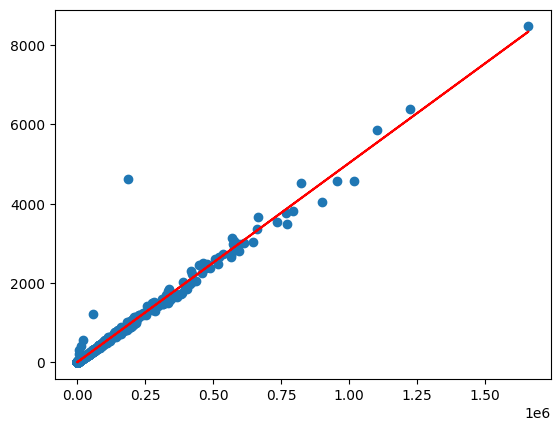

In [ ]:
plt.scatter(X_test, y_test)
plt.plot(X_test, model1.predict(X_test), color = 'red')


In [ ]:
# For inferencing(predicting for unseen target variable)
input_data = {
    'Dollars': [18500, 9000]
}

In [ ]:
df = pd.DataFrame(input_data)

In [ ]:
model1.predict( df)

array([97.78868161, 50.14455838])

In [ ]:
import os

# 1. Define the path for the new subfolder inside your Google Drive project
subfolder_path = '/content/drive/MyDrive/Freight_Cost_Project/freight_cost_prediction'
os.makedirs(subfolder_path, exist_ok=True)

# 2. Create the 'data_preprocessing.py' script file inside that subfolder
with open(os.path.join(subfolder_path, 'data_preprocessing.py'), 'w') as f:
    pass  # This creates a clean, empty python file

# 3. Create the 'model.txt' file inside that subfolder
with open(os.path.join(subfolder_path, 'model.txt'), 'w') as f:
    pass  # This creates a clean, empty text file

print("Folder structure and files created successfully inside Google Drive!")


Folder structure and files created successfully inside Google Drive!


In [2]:
import os
import shutil

# 1. Define the exact folder path where your files are located
project_folder = '/content/drive/MyDrive/Freight_Cost_Project/freight_cost_prediction'
github_temp_dir = '/content/github_upload'

# Re-create a clean local temporary staging directory
if os.path.exists(github_temp_dir):
    shutil.rmtree(github_temp_dir)
os.makedirs(github_temp_dir)

print("⏳ Scanning folder for your raw code files...")

# 2. Automatically loop through your folder and grab ONLY script/notebook extensions
for file_name in os.listdir(project_folder):
    if file_name.endswith('.py') or file_name.endswith('.ipynb'):
        src_file = os.path.join(project_folder, file_name)
        dst_file = os.path.join(github_temp_dir, file_name)

        shutil.copy(src_file, dst_file)
        print(f"✅ Prepared for GitHub: {file_name}")

print("\n🚀 All 8 code files staged successfully! Proceed to the next cell to push.")


⏳ Scanning folder for your raw code files...
✅ Prepared for GitHub: Predicting Frieght Cost.ipynb
✅ Prepared for GitHub: data_preprocessing.py
✅ Prepared for GitHub: model_evaluation.py
✅ Prepared for GitHub: predict.py
✅ Prepared for GitHub: inference_classification.py
✅ Prepared for GitHub: train_classification.py
✅ Prepared for GitHub: Invoice_Flagging.ipynb

🚀 All 8 code files staged successfully! Proceed to the next cell to push.


In [4]:
# 1. Navigate back into your prepared staging folder
%cd /content/github_upload

# 2. Clear out the broken link path configuration
!git remote remove origin

# 3. PASTE YOUR GITHUB TOKEN RIGHT HERE INSIDE THE QUOTES:
TOKEN="PASTE_YOUR_ghp_TOKEN_HERE"

# 4. Bind your secure authentication link structure
!git remote add origin https://Amita-sudo:${TOKEN}@://github.com

# 5. Push all 7 code files directly onto your live repository main branch!
!git branch -M main
!git push -u origin main --force


/content/github_upload
fatal: unable to access 'https://://github.com/': URL rejected: No host part in the URL
